In [9]:
from pathlib import Path
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings("ignore")  # Unterdrückt Warnungen für saubere Ausgabe

# Setze den Stil für die Plots
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 6)  # Standardgröße für Plots
eval_runs_dir = Path("../evalRuns")

all_runs = []

for run_dir in sorted(eval_runs_dir.iterdir()):

    if not run_dir.is_dir():
        continue

    replicates_dir = run_dir / "replicates"
    csv_path = run_dir / "results" / "runs.csv"
    json_path = run_dir / "results" / "metrics.json"

    # Check required files
    if not replicates_dir.exists():
        continue

    if not csv_path.exists():
        continue

    if not json_path.exists():
        continue

    # Count replicates
    n_replicates = len([
        d for d in replicates_dir.iterdir()
        if d.is_dir()
    ])

    # Only include experiments with 3+ replicates
    if n_replicates < 3:
        continue

    # Load CSV
    df = pd.read_csv(csv_path)

    # Load metrics.json
    with open(json_path, "r") as f:
        metrics = json.load(f)

    # Get experiment metadata
    experiment_id = metrics.get("experiment_id", run_dir.name)
    experiment_type = metrics.get("type", "unknown")
    model = metrics.get("model", "unknown")

    # Add metadata to every row
    df["experiment_id"] = experiment_id
    df["type"] = experiment_type
    df["model"] = model
    df["n_replicates"] = n_replicates

    all_runs.append(df)


# Combine all experiments
combined = pd.concat(
    all_runs,
    ignore_index=True
)

display(combined)

,run_id,valid_verdicts,terminal_errors,correct,score_coverage,end_to_end_accuracy,phase1_valid,phase1_correct,phase1_f1,phase1_compiler_failures,...,initial_failures,precision,recall,f1,accuracy,runtime_seconds,experiment_id,type,model,n_replicates
0,20260725T094738Z/run-001,93,49,54,0.654930,0.380282,113,67,0.640625,58,...,58,0.769231,0.217391,0.338983,0.580645,21622.324284,20260725T094738Z,none,llm3,3
1,20260725T094738Z/run-002,101,41,58,0.711268,0.408451,113,67,0.610169,52,...,52,0.800000,0.163265,0.271186,0.574257,21555.002167,20260725T094738Z,none,llm3,3
2,20260725T094738Z/run-003,97,45,53,0.683099,0.373239,117,73,0.650794,52,...,52,0.714286,0.106383,0.185185,0.546392,20825.405801,20260725T094738Z,none,llm3,3
3,20260726T054604Z/run-001,91,51,51,0.640845,0.359155,116,74,0.681818,49,...,49,0.636364,0.162791,0.259259,0.560440,23370.677437,20260726T054604Z,context,llm3,3
4,20260726T054604Z/run-002,99,43,54,0.697183,0.380282,120,77,0.671756,49,...,49,0.625000,0.106383,0.181818,0.545455,23803.894636,20260726T054604Z,context,llm3,3
5,20260726T054604Z/run-003,92,50,51,0.647887,0.359155,116,66,0.615385,56,...,56,0.600000,0.139535,0.226415,0.554348,23556.637645,20260726T054604Z,context,llm3,3
6,20260726T054817Z/run-001,97,45,55,0.683099,0.387324,116,71,0.640000,51,...,51,0.666667,0.133333,0.222222,0.567010,25246.337707,20260726T054817Z,all,llm3,3
7,20260726T054817Z/run-002,93,49,52,0.654930,0.366197,117,68,0.642336,43,...,43,0.888889,0.166667,0.280702,0.559140,24392.220693,20260726T054817Z,all,llm3,3
8,20260726T054817Z/run-003,91,51,49,0.640845,0.345070,111,55,0.555556,45,...,45,0.600000,0.136364,0.222222,0.538462,23755.820523,20260726T054817Z,all,llm3,3


In [11]:
# Deskriptive Statistik pro 'type'
descriptive_stats = combined.groupby("type").agg({
    "valid_verdicts": ["mean", "std", "min", "max"],
    "correct": ["mean", "std", "min", "max"],
    "terminal_errors": ["mean", "std", "min", "max"],
    "f1": ["mean", "std", "min", "max"],
    "accuracy": ["mean", "std", "min", "max"],
    "precision": ["mean", "std", "min", "max"],
    "recall": ["mean", "std", "min", "max"],
    "runtime_seconds": ["mean", "std", "min", "max"]
}).round(4)

print("\nDeskriptive Statistik pro Konfiguration:")
display(descriptive_stats)



Deskriptive Statistik pro Konfiguration:


valid_verdicts                  correct                  \
                  mean     std min  max    mean     std min max   
type                                                              
all            93.6667  3.0551  91   97    52.0  3.0000  49  55   
context        94.0000  4.3589  91   99    52.0  1.7321  51  54   
none           97.0000  4.0000  93  101    55.0  2.6458  53  58   

        terminal_errors          ... precision          recall          \
                   mean     std  ...       min     max    mean     std   
type                             ...                                     
all             48.3333  3.0551  ...    0.6000  0.8889  0.1455  0.0184   
context         48.0000  4.3589  ...    0.6000  0.6364  0.1362  0.0283   
none            45.0000  4.0000  ...    0.7143  0.8000  0.1623  0.0555   

                        runtime_seconds                                    
            min     max            mean       std         min         max  
type                                                                       
all      0.1333  0.1667      24464.7930  747.9040  23755.8205  25246.3377  
context  0.1064  0.1628      23577.0699  217.3301  23370.6774  23803.8946  
none     0.1064  0.2174      21334.2441  441.9506  20825.4058  21622.3243  

[3 rows x 32 columns]

In [15]:
# --- Assumption checks (informative, not gatekeeping given small n) ---
from scipy.stats import shapiro, levene, kruskal, f_oneway

def check_assumptions(df, metric, group_col="type"):
    groups = [g[metric].dropna().values for _, g in df.groupby(group_col)]
    print(f"\n--- {metric} ---")
    for name, vals in zip(df[group_col].unique(), groups):
        if len(vals) >= 3:
            stat, p = shapiro(vals)
            print(f"  Shapiro-Wilk ({name}, n={len(vals)}): p={p:.3f}")
    if all(len(g) >= 2 for g in groups):
        stat, p = levene(*groups)
        print(f"  Levene's test (homogeneity of variance): p={p:.3f}")

for metric in metrics_to_plot:
    check_assumptions(combined, metric)


--- f1 ---
  Shapiro-Wilk (none, n=3): p=0.000
  Shapiro-Wilk (context, n=3): p=0.833
  Shapiro-Wilk (all, n=3): p=0.870
  Levene's test (homogeneity of variance): p=0.541

--- accuracy ---
  Shapiro-Wilk (none, n=3): p=0.516
  Shapiro-Wilk (context, n=3): p=0.795
  Shapiro-Wilk (all, n=3): p=0.337
  Levene's test (homogeneity of variance): p=0.761

--- precision ---
  Shapiro-Wilk (none, n=3): p=0.424
  Shapiro-Wilk (context, n=3): p=0.593
  Shapiro-Wilk (all, n=3): p=0.692
  Levene's test (homogeneity of variance): p=0.343

--- recall ---
  Shapiro-Wilk (none, n=3): p=0.157
  Shapiro-Wilk (context, n=3): p=0.807
  Shapiro-Wilk (all, n=3): p=0.973
  Levene's test (homogeneity of variance): p=0.423

--- runtime_seconds ---
  Shapiro-Wilk (none, n=3): p=0.839
  Shapiro-Wilk (context, n=3): p=0.844
  Shapiro-Wilk (all, n=3): p=0.146
  Levene's test (homogeneity of variance): p=0.505


In [16]:
# --- Prefer non-parametric test given tiny n and unverifiable normality ---
def group_comparison(df, metric, group_col="type"):
    groups = [g[metric].dropna().values for _, g in df.groupby(group_col)]
    labels = list(df.groupby(group_col).groups.keys())

    # Kruskal-Wallis: doesn't assume normality, more appropriate here
    h_stat, p_kw = kruskal(*groups)

    # eta-squared as effect size (works for both ANOVA and KW approx)
    n_total = sum(len(g) for g in groups)
    eta_sq = (h_stat - len(groups) + 1) / (n_total - len(groups))

    print(f"{metric}: Kruskal-Wallis H={h_stat:.3f}, p={p_kw:.4f}, "
          f"eta²≈{eta_sq:.3f}")
    return p_kw

results = {m: group_comparison(combined, m) for m in metrics_to_plot}

f1: Kruskal-Wallis H=0.800, p=0.6703, eta²≈-0.200
accuracy: Kruskal-Wallis H=1.689, p=0.4298, eta²≈-0.052
precision: Kruskal-Wallis H=3.518, p=0.1722, eta²≈0.253
recall: Kruskal-Wallis H=0.560, p=0.7557, eta²≈-0.240
runtime_seconds: Kruskal-Wallis H=6.489, p=0.0390, eta²≈0.748


In [22]:
# --- Bootstrapped CIs instead of relying on std/SEM with n=3 ---
# Define the canonical order once, use it everywhere
type_order = ["none", "context", "all"]

# Make 'type' a categorical with this order — this makes groupby,
# sort_values, and seaborn's default ordering all follow it automatically
combined["type"] = pd.Categorical(combined["type"], categories=type_order, ordered=True)

def bootstrap_ci(data, n_boot=5000, ci=95):
    data = np.asarray(data)
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True))
                  for _ in range(n_boot)]
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

summary_rows = []
for metric in metrics_to_plot:
    for t, g in combined.groupby("type", observed=True):
        mean, lo, hi = bootstrap_ci(g[metric].dropna())
        summary_rows.append({"type": t, "metric": metric,
                              "mean": mean, "ci_lower": lo, "ci_upper": hi,
                              "n": len(g)})

summary_df = pd.DataFrame(summary_rows)
summary_df["type"] = pd.Categorical(summary_df["type"], categories=type_order, ordered=True)
summary_df = summary_df.sort_values(["metric", "type"]).reset_index(drop=True)
display(summary_df)

,type,metric,mean,ci_lower,ci_upper,n
0,none,accuracy,0.567098,0.546392,0.580645,3
1,context,accuracy,0.553414,0.545455,0.560440,3
2,all,accuracy,0.554871,0.538462,0.567010,3
3,none,f1,0.265118,0.185185,0.338983,3
4,context,f1,0.222498,0.181818,0.259259,3
5,all,f1,0.241715,0.222222,0.280702,3
6,none,precision,0.761172,0.714286,0.800000,3
7,context,precision,0.620455,0.600000,0.636364,3
8,all,precision,0.718519,0.600000,0.888889,3
9,none,recall,0.162347,0.106383,0.217391,3


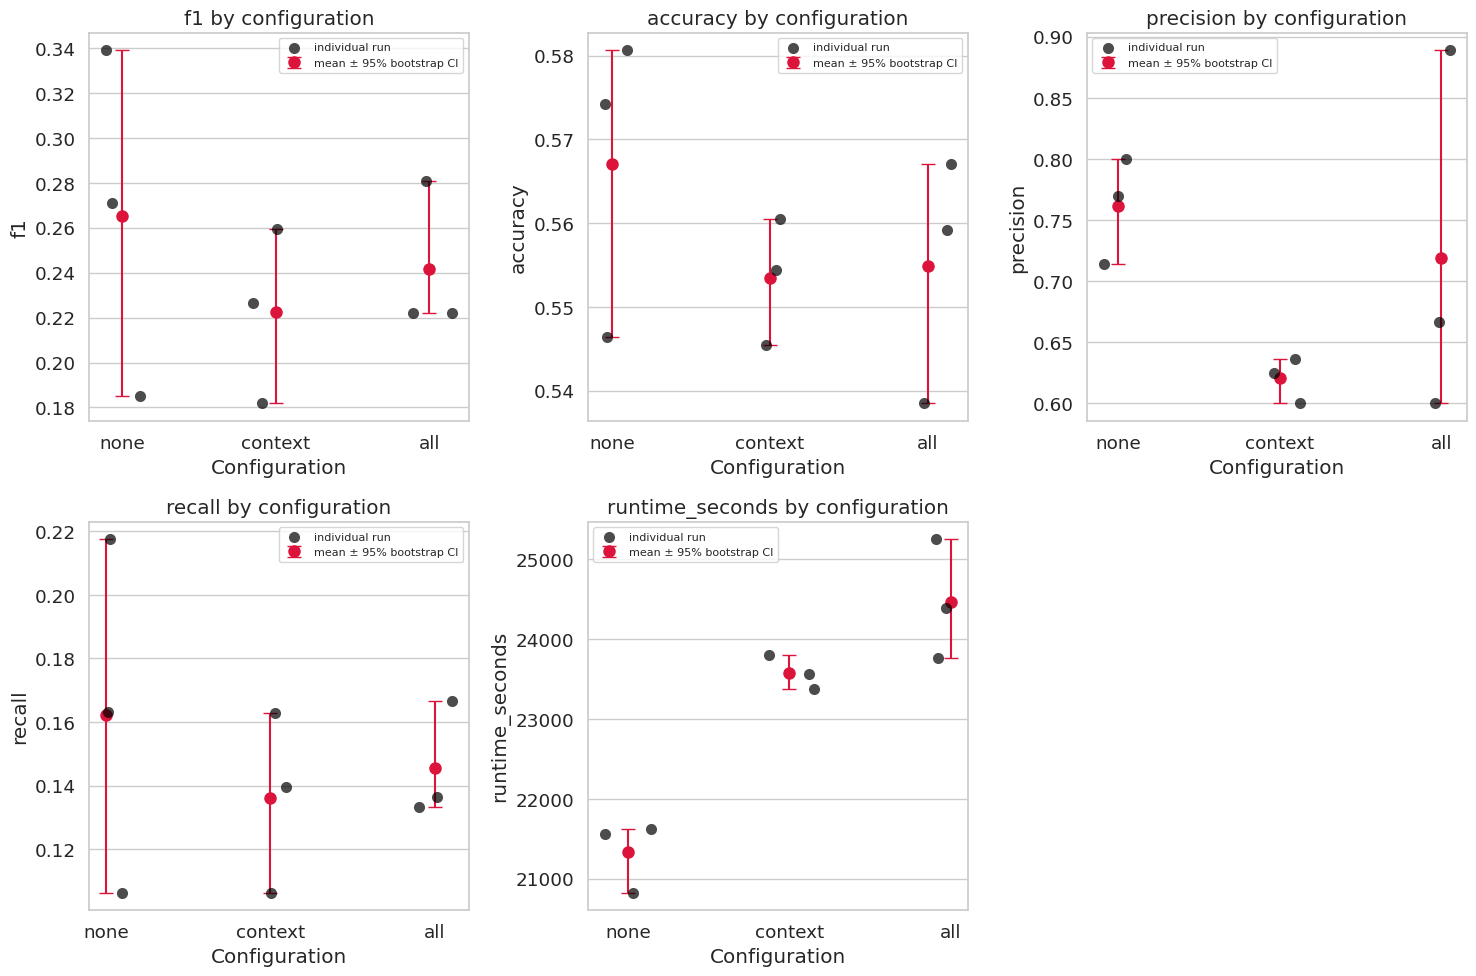

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]

    sns.stripplot(
        data=combined, x="type", y=metric, ax=ax,
        order=type_order,
        size=8, alpha=0.7, jitter=0.15, color="black",
        label="individual run"
    )

    sub = summary_df[summary_df["metric"] == metric].set_index("type").loc[type_order].reset_index()
    ax.errorbar(
        x=range(len(sub)), y=sub["mean"],
        yerr=[sub["mean"] - sub["ci_lower"], sub["ci_upper"] - sub["mean"]],
        fmt="o", color="crimson", capsize=5, markersize=8,
        label="mean ± 95% bootstrap CI"
    )

    ax.set_xticks(range(len(type_order)))
    ax.set_xticklabels(type_order)
    ax.set_title(f"{metric} by configuration")
    ax.set_xlabel("Configuration")
    ax.set_ylabel(metric)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc="best")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [24]:
from itertools import combinations
from scipy.stats import mannwhitneyu

def pairwise_tests(df, metric, group_col="type", order=None):
    groups = order or df[group_col].unique()
    pairs = list(combinations(groups, 2))
    raw_pvals = []

    for g1, g2 in pairs:
        vals1 = df[df[group_col] == g1][metric].dropna()
        vals2 = df[df[group_col] == g2][metric].dropna()
        stat, p = mannwhitneyu(vals1, vals2, alternative="two-sided")
        raw_pvals.append(p)

    # Bonferroni correction: multiply each p by number of comparisons
    corrected = [min(p * len(pairs), 1.0) for p in raw_pvals]

    return pd.DataFrame({
        "pair": [f"{a} vs {b}" for a, b in pairs],
        "p_raw": raw_pvals,
        "p_bonferroni": corrected,
    })

for metric in metrics_to_plot:
    print(f"\n--- {metric} ---")
    display(pairwise_tests(combined, metric, order=type_order))


--- f1 ---


,pair,p_raw,p_bonferroni
0,none vs context,0.4,1.0
1,none vs all,1.0,1.0
2,context vs all,1.0,1.0



--- accuracy ---


,pair,p_raw,p_bonferroni
0,none vs context,0.4,1.0
1,none vs all,0.4,1.0
2,context vs all,1.0,1.0



--- precision ---


,pair,p_raw,p_bonferroni
0,none vs context,0.100000,0.3
1,none vs all,0.700000,1.0
2,context vs all,0.506555,1.0



--- recall ---


,pair,p_raw,p_bonferroni
0,none vs context,0.506555,1.0
1,none vs all,1.000000,1.0
2,context vs all,1.000000,1.0



--- runtime_seconds ---


,pair,p_raw,p_bonferroni
0,none vs context,0.1,0.3
1,none vs all,0.1,0.3
2,context vs all,0.2,0.6


In [25]:
def leave_one_out_means(df, metric, group_col="type"):
    results = []
    for t, g in df.groupby(group_col, observed=True):
        vals = g[metric].dropna().values
        for i in range(len(vals)):
            loo_mean = np.mean(np.delete(vals, i))
            results.append({"type": t, "excluded_idx": i,
                             "loo_mean": loo_mean, "full_mean": vals.mean()})
    return pd.DataFrame(results)

leave_one_out_means(combined, "f1")

,type,excluded_idx,loo_mean,full_mean
0,none,0,0.228186,0.265118
1,none,1,0.262084,0.265118
2,none,2,0.305085,0.265118
3,context,0,0.204117,0.222498
4,context,1,0.242837,0.222498
5,context,2,0.220539,0.222498
6,all,0,0.251462,0.241715
7,all,1,0.222222,0.241715
8,all,2,0.251462,0.241715


In [29]:
def cliffs_delta(x, y):
    x, y = np.asarray(x), np.asarray(y)
    n_x, n_y = len(x), len(y)
    greater = sum(xi > yi for xi in x for yi in y)
    less = sum(xi < yi for xi in x for yi in y)
    return (greater - less) / (n_x * n_y)

for metric in metrics_to_plot:
    print(f"\n--- {metric} (Cliff's delta) ---")
    for g1, g2 in combinations(type_order, 2):
        v1 = combined[combined["type"] == g1][metric].dropna()
        v2 = combined[combined["type"] == g2][metric].dropna()
        d = cliffs_delta(v1, v2)
        print(f"  {g1} vs {g2}: δ={d:.3f}")


--- f1 (Cliff's delta) ---
  none vs context: δ=0.556
  none vs all: δ=0.111
  context vs all: δ=-0.111

--- accuracy (Cliff's delta) ---
  none vs context: δ=0.556
  none vs all: δ=0.556
  context vs all: δ=-0.111

--- precision (Cliff's delta) ---
  none vs context: δ=1.000
  none vs all: δ=0.333
  context vs all: δ=-0.444

--- recall (Cliff's delta) ---
  none vs context: δ=0.444
  none vs all: δ=0.111
  context vs all: δ=-0.111

--- runtime_seconds (Cliff's delta) ---
  none vs context: δ=-1.000
  none vs all: δ=-1.000
  context vs all: δ=-0.778


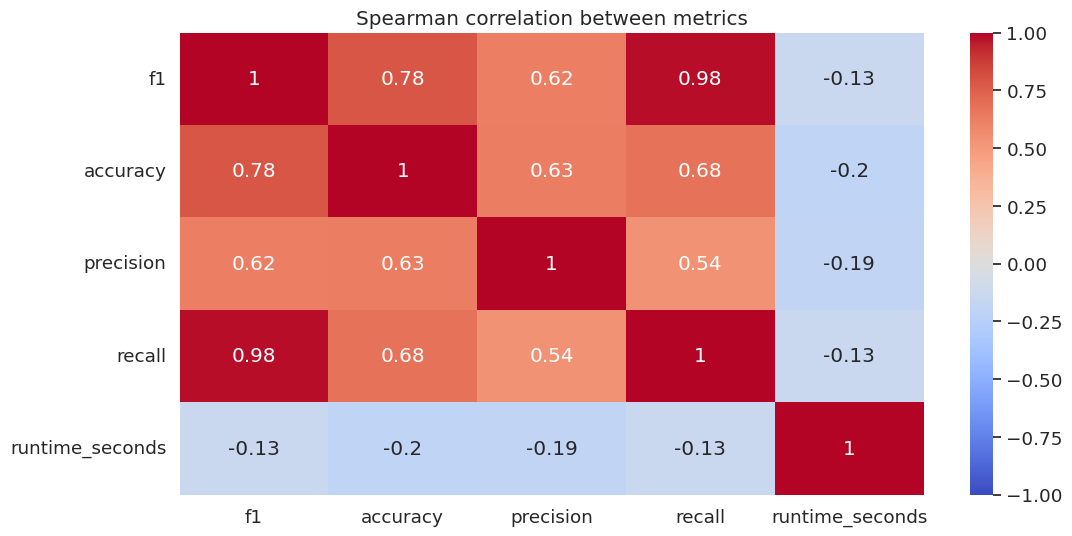

In [30]:
metric_corr = combined[metrics_to_plot].corr(method="spearman")
sns.heatmap(metric_corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation between metrics")
plt.show()

In [31]:
def permutation_test(x, y, n_perm=10000, seed=42):
    rng = np.random.default_rng(seed)
    x, y = np.asarray(x), np.asarray(y)
    observed_diff = np.mean(x) - np.mean(y)

    combined_vals = np.concatenate([x, y])
    n_x = len(x)
    count = 0

    for _ in range(n_perm):
        shuffled = rng.permutation(combined_vals)
        new_x, new_y = shuffled[:n_x], shuffled[n_x:]
        diff = np.mean(new_x) - np.mean(new_y)
        if abs(diff) >= abs(observed_diff):
            count += 1

    p_value = count / n_perm
    return observed_diff, p_value

for metric in metrics_to_plot:
    print(f"\n--- {metric} (permutation test) ---")
    for g1, g2 in combinations(type_order, 2):
        v1 = combined[combined["type"] == g1][metric].dropna()
        v2 = combined[combined["type"] == g2][metric].dropna()
        diff, p = permutation_test(v1, v2)
        print(f"  {g1} vs {g2}: mean diff={diff:.4f}, p={p:.4f}")


--- f1 (permutation test) ---
  none vs context: mean diff=0.0426, p=0.3576
  none vs all: mean diff=0.0234, p=0.6750
  context vs all: mean diff=-0.0192, p=0.6057

--- accuracy (permutation test) ---
  none vs context: mean diff=0.0137, p=0.2979
  none vs all: mean diff=0.0122, p=0.4095
  context vs all: mean diff=-0.0015, p=0.9652

--- precision (permutation test) ---
  none vs context: mean diff=0.1407, p=0.0313
  none vs all: mean diff=0.0427, p=0.6322
  context vs all: mean diff=-0.0981, p=0.4003

--- recall (permutation test) ---
  none vs context: mean diff=0.0261, p=0.4989
  none vs all: mean diff=0.0169, p=0.8067
  context vs all: mean diff=-0.0092, p=0.6356

--- runtime_seconds (permutation test) ---
  none vs context: mean diff=-2242.8258, p=0.1008
  none vs all: mean diff=-3130.5489, p=0.1008
  context vs all: mean diff=-887.7231, p=0.1974


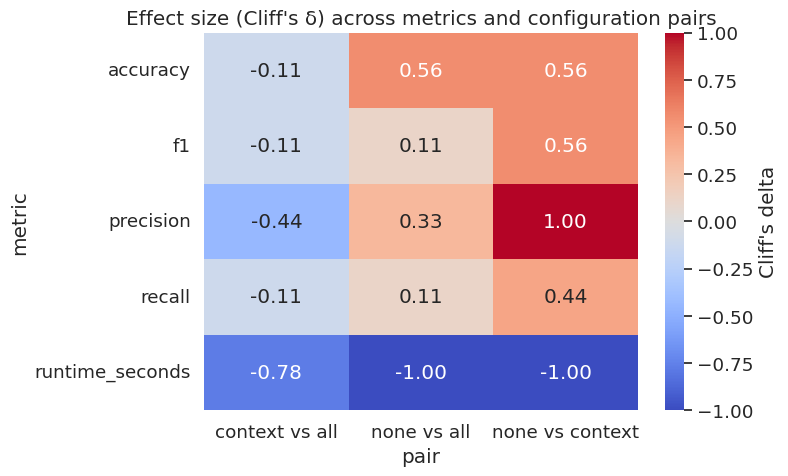

In [32]:
delta_rows = []
for metric in metrics_to_plot:
    for g1, g2 in combinations(type_order, 2):
        v1 = combined[combined["type"] == g1][metric].dropna()
        v2 = combined[combined["type"] == g2][metric].dropna()
        d = cliffs_delta(v1, v2)
        delta_rows.append({"metric": metric, "pair": f"{g1} vs {g2}", "delta": d})

delta_df = pd.DataFrame(delta_rows).pivot(index="metric", columns="pair", values="delta")

plt.figure(figsize=(8, 5))
sns.heatmap(delta_df, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            fmt=".2f", cbar_kws={"label": "Cliff's delta"})
plt.title("Effect size (Cliff's δ) across metrics and configuration pairs")
plt.tight_layout()
plt.show()

In [33]:
# Direction: for these metrics, higher is better, except runtime (lower is better)
higher_is_better = {"f1": True, "accuracy": True, "precision": True,
                     "recall": True, "runtime_seconds": False}

norm_rows = []
for metric, higher_better in higher_is_better.items():
    vals = combined.groupby("type", observed=True)[metric].mean().loc[type_order]
    if higher_better:
        norm = (vals - vals.min()) / (vals.max() - vals.min())
    else:
        norm = (vals.max() - vals) / (vals.max() - vals.min())
    norm_rows.append(norm.rename(metric))

norm_df = pd.concat(norm_rows, axis=1)
norm_df["composite_score"] = norm_df.mean(axis=1)
display(norm_df.round(3))

,f1,accuracy,precision,recall,runtime_seconds,composite_score
type,,,,,,
none,1.000,1.000,1.000,1.000,1.000,1.000
context,0.000,0.000,0.000,0.000,0.284,0.057
all,0.451,0.106,0.697,0.353,0.000,0.321


In [34]:
final_rows = []
for metric in metrics_to_plot:
    kw_p = results[metric]  # from your earlier Kruskal-Wallis loop
    for t in type_order:
        row = summary_df[(summary_df["metric"] == metric) & (summary_df["type"] == t)].iloc[0]
        final_rows.append({
            "metric": metric,
            "type": t,
            "mean": round(row["mean"], 4),
            "95%_CI": f"[{row['ci_lower']:.4f}, {row['ci_upper']:.4f}]",
            "kruskal_wallis_p": round(kw_p, 4),
        })

final_table = pd.DataFrame(final_rows)
display(final_table)

,metric,type,mean,95%_CI,kruskal_wallis_p
0,f1,none,0.2651,"[0.1852, 0.3390]",0.6703
1,f1,context,0.2225,"[0.1818, 0.2593]",0.6703
2,f1,all,0.2417,"[0.2222, 0.2807]",0.6703
3,accuracy,none,0.5671,"[0.5464, 0.5806]",0.4298
4,accuracy,context,0.5534,"[0.5455, 0.5604]",0.4298
5,accuracy,all,0.5549,"[0.5385, 0.5670]",0.4298
6,precision,none,0.7612,"[0.7143, 0.8000]",0.1722
7,precision,context,0.6205,"[0.6000, 0.6364]",0.1722
8,precision,all,0.7185,"[0.6000, 0.8889]",0.1722
9,recall,none,0.1623,"[0.1064, 0.2174]",0.7557
